# CS647 Image Processing
## Exercise 2  (24.02.2026)

# Task 1: Computing Fourier Transform of an Image

* Load an image to python and convert to gray levels.
* Compute the Fast Fourier Transform [FFT] (using scipy) and inspect the result.
* Compute the Inverse FFT.


In [123]:
# load packages
from scipy.fft import fft2, ifft2, fftshift, ifftshift
import numpy as np
import pylab as py
from scipy import datasets
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
import timeit


(768, 1024, 3)


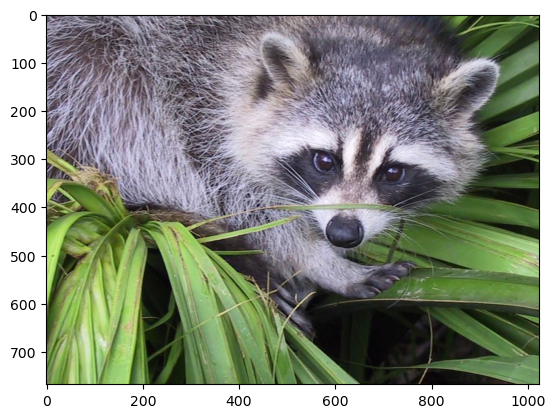

In [124]:
# load image
colorimg = datasets.face()
print(colorimg.shape)
plt.imshow(colorimg)
plt.show()

(768, 1024)


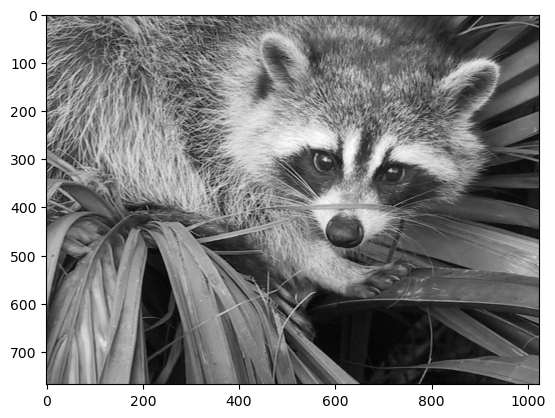

In [125]:
# convert to grayscale
grayimg = colorimg.mean(axis=-1)
print(grayimg.shape)
plt.imshow(grayimg,cmap='gray',vmin=0,vmax=255)
plt.show()

In [126]:
# 1. Take the fourier transform
F_img = fft2(grayimg)
print(f"Fourier Shape: {F_img.shape}, Type: {F_img.dtype}") 
# now the image signal in the frequency space is complex, i.e. each value has a real and an imaginary part

# 2. Inverse transform
IF_img = ifft2(F_img)

# 3. Clean up the result
# We take the real part because the imaginary part is just rounding noise
IF_img_real = np.real(IF_img)

print(f"Reconstructed Type: {IF_img_real.dtype}")
print(f"Original Type: {grayimg.dtype}")

# 4. Correct way to compare floating point results
# Don't use np.equal; use np.allclose to account for tiny math errors
is_equal = np.allclose(grayimg, IF_img_real)
print(f"Can we perfectly reconstruct the images (ignoring minor difference due to dtype changes)? {is_equal}")

Fourier Shape: (768, 1024), Type: complex128
Reconstructed Type: float64
Original Type: float64
Can we perfectly reconstruct the images (ignoring minor difference due to dtype changes)? True


# Task 2: Visualizing Fourier Transformed Images

* Shift the quadrants around so that low spatial frequencies are in the center of the 2D Fourier transformed image.
* Calculate a 2D power spectrum (magnitude values of the Fourier transform).

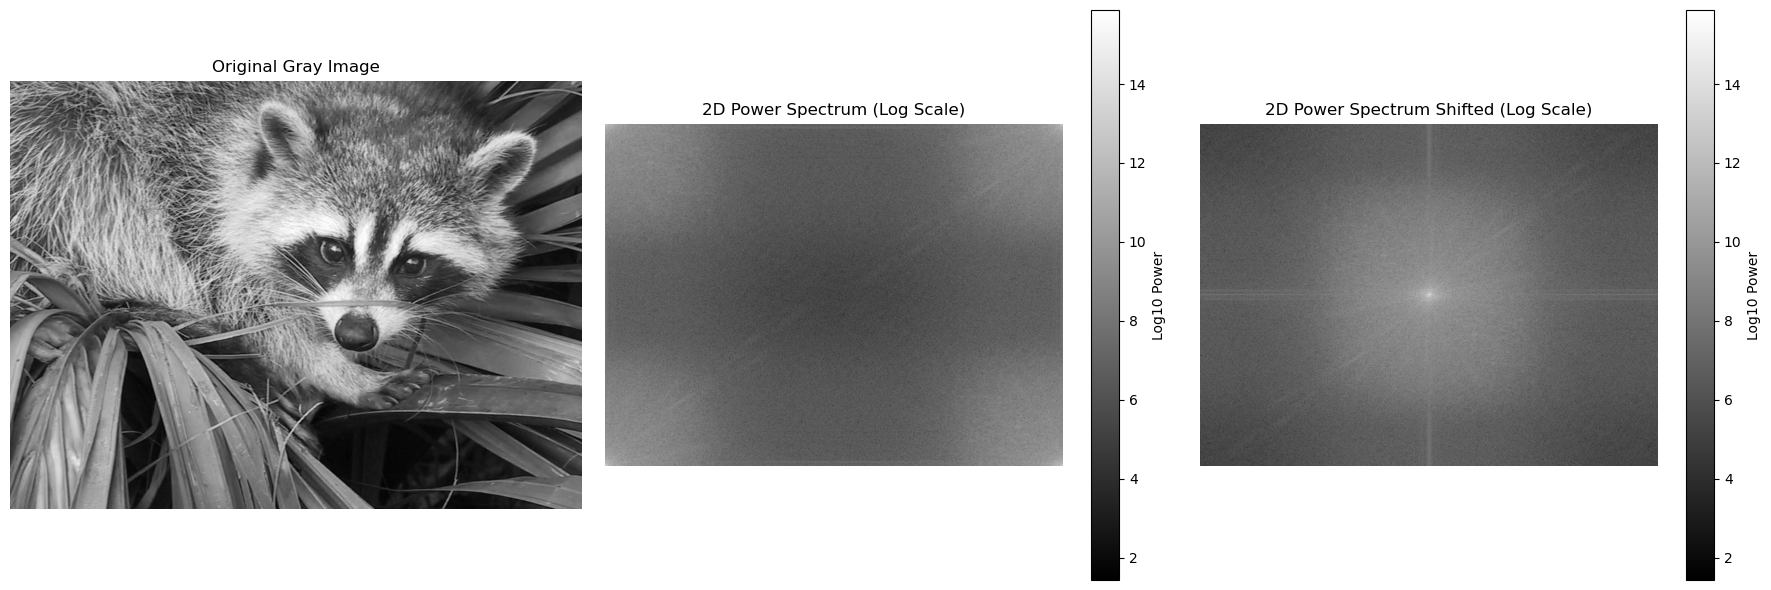

In [127]:
# 1. Shift the zero-frequency component to the center
F_shifted = fftshift(F_img)

# 2. Calculate the Power Spectrum (Magnitude Squared)
# We use np.abs() to get the magnitude of the complex numbers
power_spectrum = np.abs(F_img)**2
power_spectrum_shifted = np.abs(F_shifted)**2

# 3. Apply a Log Transform for visualization
# Adding 1 prevents log(0) errors
log_power_spectrum = np.log10(1 + power_spectrum)
log_power_spectrum_shifted = np.log10(1 + power_spectrum_shifted)

# 4. Plotting
plt.figure(figsize=(18, 6))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(grayimg, cmap='gray')
plt.title('Original Gray Image')
plt.axis('off')

# Power Spectrum
plt.subplot(1, 3, 2)
plt.imshow(log_power_spectrum, cmap='gray')
plt.title('2D Power Spectrum (Log Scale)')
plt.colorbar(label='Log10 Power')
plt.axis('off')

# Power Spectrum (Shifted image)
plt.subplot(1, 3, 3)
plt.imshow(log_power_spectrum_shifted, cmap='gray')
plt.title('2D Power Spectrum Shifted (Log Scale)')
plt.colorbar(label='Log10 Power')
plt.axis('off')

plt.tight_layout()
plt.show()

In [128]:
# come back to spacial domain
F_shiftedback = ifftshift(F_shifted)
IF_img_shiftedback = ifft2(F_shiftedback)

IF_img_real_sb = np.real(IF_img_shiftedback)

# 4. Correct way to compare floating point results
# Don't use np.equal; use np.allclose to account for tiny math errors
is_equal = np.allclose(grayimg, IF_img_real_sb)
print(f"Can we perfectly reconstruct the images (ignoring minor difference due to dtype changes)? {is_equal}")

Can we perfectly reconstruct the images (ignoring minor difference due to dtype changes)? True


# Task 3: Working for Images in the Frequency Domain (after FFT)
* Implement a low-pass filter as a 2D Gaussian on the same size as the image.
* Apply the filter with different standard deviations of the Gaussian as a point-wise multiplication in the frequency domain

In [143]:
# define filter

def gaussian_low_pass(img, sigma):
    # 1. Prepare coordinates for the Gaussian mask
    height, width = img.shape
    center_y, center_x = height // 2, width // 2
    y, x = np.ogrid[:height, :width]
    
    # 2. Create the 2D Gaussian mask
    # Formula: exp(-(dist^2) / (2 * sigma^2))
    dist_sq = (x - center_x)**2 + (y - center_y)**2
    mask = np.exp(-dist_sq / (2 * sigma**2))
    
    # 3. Process the Image in Frequency Domain
    f_img = fft2(img)
    f_shifted = fftshift(f_img)
    
    # 4. Point-wise multiplication (Filtering)
    f_filtered_shifted = f_shifted * mask
    
    # 5. Inverse FFT: Shift back and transform
    f_filtered = ifftshift(f_filtered_shifted)
    img_filtered = np.real(ifft2(f_filtered))
    
    return img_filtered, mask


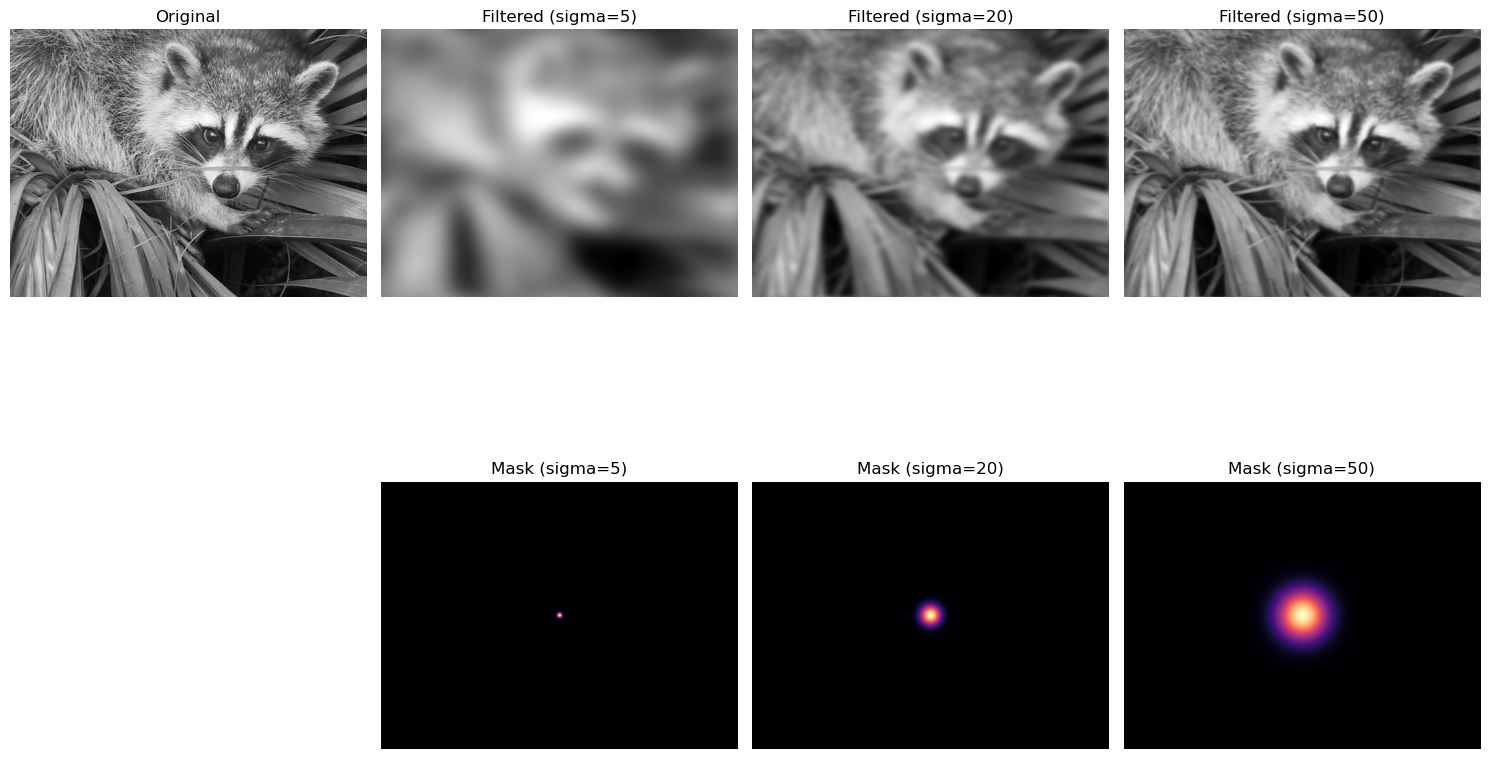

In [144]:
# --- Experiment with different Sigmas ---
sigmas = [5, 20, 50]
plt.figure(figsize=(15, 10))

# Show Original
plt.subplot(2, len(sigmas) + 1, 1)
plt.imshow(grayimg, cmap='gray')
plt.title("Original")
plt.axis('off')

for i, s in enumerate(sigmas):
    filtered_res, mask_res = gaussian_low_pass(grayimg, s)
    
    # Plot the Filtered Image
    plt.subplot(2, len(sigmas) + 1, i + 2)
    plt.imshow(filtered_res, cmap='gray')
    plt.title(f"Filtered (sigma={s})")
    plt.axis('off')
    
    # Plot the Mask (Frequency Domain view)
    plt.subplot(2, len(sigmas) + 1, i + len(sigmas) + 3)
    plt.imshow(mask_res, cmap='magma')
    plt.title(f"Mask (sigma={s})")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [138]:
# 1. Setup Parameters
sigma = 5.0
size = 25  # Size of the spatial kernel (must be large enough for the Gaussian)
y, x = np.ogrid[-size//2 : size//2+1, -size//2 : size//2+1]
kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
kernel /= kernel.sum()  # Normalize so the image brightness doesn't change

# 2. Spatial Domain Convolution
t1 = timeit.default_timer()
img_spatial = convolve(grayimg, kernel, mode='constant')
t2 = timeit.default_timer()
spacial_time = t2-t1
print(f"Spacial domain operation took {round(spacial_time,2)} seconds.")

# 3. Frequency Domain Multiplication
t1 = timeit.default_timer()
img_freq = gaussian_low_pass(grayimg,sigma)
t2 = timeit.default_timer()
freq_time = t2-t1
print(f"Frequency domain operation took {round(freq_time,2)} seconds.")




Spacial domain operation took 0.32 seconds.
Frequency domain operation took 0.02 seconds.
